In [14]:
#  definindo funções de matemática 

import numpy as np

def crossprod(A, B):
    C=np.zeros(3)
    C[0]=A[1]*B[2]-A[2]*B[1]
    C[1]=A[2]*B[0]-A[0]*B[2]
    C[2]=A[0]*B[1]-A[1]*B[0]
    return C 

def mod(F):
    mod=np.sqrt(F[0]*F[0]+F[1]*F[1]+F[2]*F[2])	
    return mod

# teste
A=np.array([1.0,2.0,3.0])
B=np.array([4.0,5.0,6.0])
C=crossprod(A,B)
print("Produto vetorial A x B = ",C)
print("Módulo do vetor C = ",mod(C))

Produto vetorial A x B =  [-3.  6. -3.]
Módulo do vetor C =  7.3484692283495345


In [ ]:
# definindo funções de física
def FLorentz(q, v, B): # força de Lorentz
    F=np.zeros(3)
    F = q*crossprod(v, B)
    return F    

def Velocity(v0, a, t):
    v = np.zeros(3)
    vers = np.zeros(3) # versor na direção de v
    for i in range(3): 
        v[i] = v0[i] + a[i] * t

    modv = mod(v) # deve ser diferente de zero
    modv0 = mod(v0)
    for i in range(3):
        vers[i] = v[i] / modv
        v[i] = modv0 * vers[i] 
    return v

def Position(r0, v0, a, t):
    r = np.zeros(3)
    for i in range(3): 
        r[i]=r0[i]+v0[i]*t+(a[i]*t*t)/2
    return r    

def RelMass(m, v0): # massa relativística
    c = 299792458 # m/s
    beta = mod(v0) / c
    #print("beta = %.3e" % beta)
    mR = m / np.sqrt(1 - beta * beta)
    #print(np.sqrt(1 - beta * beta))
    #print("mR = %.3e" % mR)
    return mR


import numpy as np
def Bdipolar(r): # campo magnético dipolar

    # constantes
    mi0=np.pi*4E-7 # T.m/A
    m=1E24 # T.m^3, momento magnético da Terra
    mod_r = mod(r)
    if mod_r > 1:
        for i in range(3):

            cos_theta = r[2]/mod_r
            sen_theta = np.sqrt(1 - cos_theta*cos_theta)
            
            sen_phi=r[1]/np.sqrt(r[0]*r[0]+r[1]*r[1])
            cos_phi=r[0]/np.sqrt(r[0]*r[0]+r[1]*r[1])

            Br=(2*m*mi0*cos_theta)/(4*np.pi*mod_r*mod_r*mod_r)
            Btheta=(m*mi0*sen_theta)/(4*np.pi*mod_r*mod_r*mod_r)

            B = np.zeros(3)
            B[0]=(Br*sen_theta*cos_phi + Btheta*cos_theta*cos_phi)
            B[1]=(Br*sen_theta*sen_phi + Btheta*cos_theta*sen_phi)
            B[2]=(Br*cos_theta - Btheta*sen_theta)
            return B
    else:
        B=np.array([0.0,1E-4,0.0])
        return B        


def Energy_to_velocity(E, m, v0): # E em eV, m em kg
    e=1.602176634E-19 # C
    c=299792458 # m/s
    E_joules=E*e
    beta=np.sqrt(1-((m*c*c)/(E_joules))**2)
    if beta < 1:
        v=beta*c
    else:
        print("Velocidade maior que a da luz.")
        return None

    vector_v= v * (v0 / mod(v0)) # vetor velocidade
    #print (beta)
   
    return vector_v


def RelMass_ultrarelativistic(E, m): # massa relativística
    # Ennergy_to_gamma 
    e=1.602176634E-19 # C
    c=299792458 # m/s
    E_joules=E*e
    gamma = E_joules / (m * c * c)
    mR = m * gamma
    #print("mR = %.3e" % mR)
    return mR

mR = RelMass_ultrarelativistic(1e17, 1.67e-27) # E em eV, m em kg
# teste
q=15.0
v=np.array([0.0,1.0,0.0])
B=np.array([0.0,0.0,1.0])
F=FLorentz(q, v, B)
print("Força de Lorentz F = ",F)
r = np.array([1.0,0.0,0.0])
B = Bdipolar(r)
print("Campo magnético dipolar B = ",B)



Força de Lorentz F =  [15.  0.  0.]
Campo magnético dipolar B =  [0.     0.0001 0.    ]


In [30]:
import pandas as pd

#constantes 
c = 299792458 # m/s
e = 1.6e-19 # C
mp = 1.67e-27 # kg
u = 1.66e-27 # kg

def main(q, m, r0, v0, B0):

    kpc_to_m = 3.086e19
    r0_m = r0 * kpc_to_m
        
    modv=mod(v0)
    modB=mod(B0)
    mR=RelMass(m,v0)
    rL0=mR*modv/(q*modB) #raio de Larmor
    T=2*np.pi*mR/(q*modB) # periodo de giro
    t=T/1000
    
    positions_kpc = []
    for i in range(30000):
        B=Bdipolar(r0_m)
        
        print(B)
        modB=mod(B)
        rL=mR*modv/(q*modB)
        modr=mod(r0_m)
        #if i>0: print("%.3e %.3e %.3e \n" % (t*i,modr,rL))
        F=FLorentz(q,v0,B)
        modF=mod(F)
        a=np.zeros(3)
        for j in range(3):
            a[j]=F[j]/mR
        v=Velocity(v0,a,t)
        r=Position(r0_m,v0,a,t)
        x_kpc=r[0]/ kpc_to_m
        y_kpc=r[1]/ kpc_to_m
        z_kpc=r[2]/ kpc_to_m

        positions_kpc.append([x_kpc, y_kpc, z_kpc])
    
        for j in range(3):
            r0_m[j]=r[j]
            v0[j]=v[j]
  

    df = pd.DataFrame(positions_kpc, columns=['x', 'y', 'z']) 

    return df




In [32]:
import matplotlib.pyplot as plt

def plot_trajectory(df, name):
    plt.switch_backend('TkAgg') 
    fig = plt.figure()
    ax = plt.axes(projection='3d')
    ax.plot3D(df['x'], df['y'], df['z'], 'purple')
    ax.set_xlabel('Eixo X')
    ax.set_ylabel('Eixo Y')
    ax.set_zlabel('Eixo Z')
    ax.set_title(f'Gráfico da {name}')
    plt.show()



q=1*e
m=mp
E = 10**9 # eV
r0_kpc = np.array([0.0,3E-8,-3E-8])
v0=[9000,0,0]
B0=[1E4,1E4,0.0]
df_proton = main(q, m, r0_kpc, v0, B0)
#print(df_proton)
plot_trajectory(df_proton, 'trajetória do próton no Campo Dipolar - E=10^9 eV')


[-0.00000000e+00 -6.68335817e-20  2.22778606e-20]
[-3.01287718e-42 -6.68335817e-20  2.22778606e-20]
[-6.02575437e-42 -6.68335817e-20  2.22778606e-20]
[-9.03863155e-42 -6.68335817e-20  2.22778606e-20]
[-1.20515087e-41 -6.68335817e-20  2.22778606e-20]
[-1.50643859e-41 -6.68335817e-20  2.22778606e-20]
[-1.80772631e-41 -6.68335817e-20  2.22778606e-20]
[-2.10901403e-41 -6.68335817e-20  2.22778606e-20]
[-2.41030175e-41 -6.68335817e-20  2.22778606e-20]
[-2.71158946e-41 -6.68335817e-20  2.22778606e-20]
[-3.01287718e-41 -6.68335817e-20  2.22778606e-20]
[-3.31416490e-41 -6.68335817e-20  2.22778606e-20]
[-3.61545262e-41 -6.68335817e-20  2.22778606e-20]
[-3.91674034e-41 -6.68335817e-20  2.22778606e-20]
[-4.21802806e-41 -6.68335817e-20  2.22778606e-20]
[-4.51931577e-41 -6.68335817e-20  2.22778606e-20]
[-4.82060349e-41 -6.68335817e-20  2.22778606e-20]
[-5.12189121e-41 -6.68335817e-20  2.22778606e-20]
[-5.42317893e-41 -6.68335817e-20  2.22778606e-20]
[-5.72446665e-41 -6.68335817e-20  2.22778606e-20]


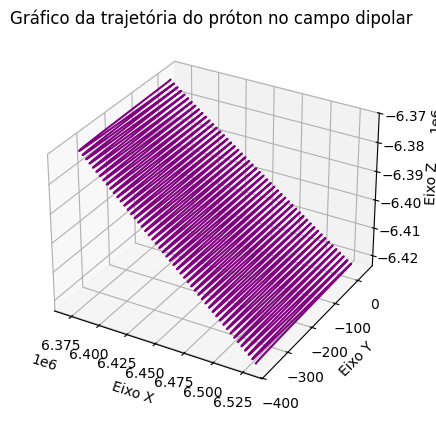

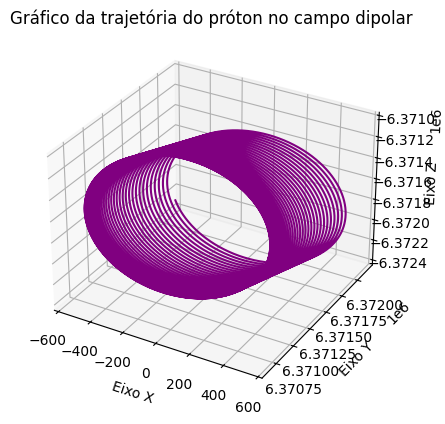

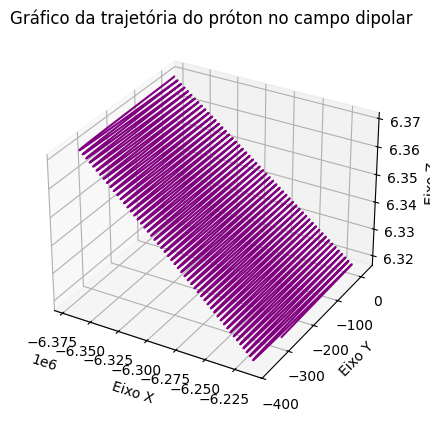

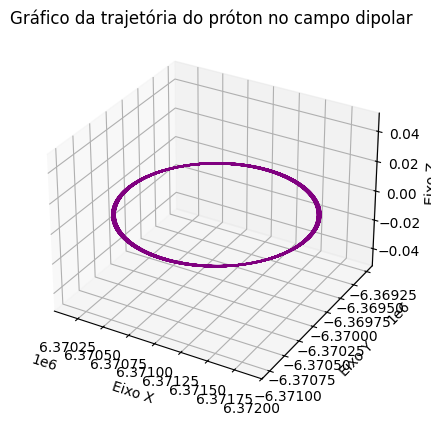

In [ ]:
#rodando para o próton com campo dipolar

r_terra=6371E3 # raio da Terra em metros
s=300000

# dist. 1

q=1*e
m=mp
r0=[r_terra,0.0,-r_terra]
v0= Energy_to_velocity(E, m, np.array([0.0, 1.0, 0.0]))
B0=[0.0,1E4,0.0]
df_proton = main(q, m, r0, v0, B0)
#print(df_proton)
plot_trajectory(df_proton, 'trajetória do próton no campo dipolar')

#  dist. 2

q=1*e
m=mp
r0=[0.0,r_terra,-r_terra]
v0= Energy_to_velocity(E, m, np.array([0.0, 1.0, 0.0]))
B0=[1E4,1E4,0.0]
df_proton = main(q, m, r0, v0, B0)
#print(df_proton)
plot_trajectory(df_proton, 'trajetória do próton no campo dipolar')
